In [57]:
!pip install -q flaml lightgbm

In [58]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

from flaml import AutoML

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

os.makedirs("figures_lab2", exist_ok=True)

In [59]:
selected_cols = [
    "Count_subj",
    "rr_interval",
    "p_end",
    "qrs_onset",
    "qrs_end",
    "p_axis",
    "qrs_axis",
    "t_axis",
    "Healthy_Status"
]

In [60]:
csv_path = "/kaggle/input/datasets/ahmadhamed1046/mydataset/module3_dataset.csv"

df_raw = pd.read_csv(csv_path)
print("Исходный размер датасета:", df_raw.shape)
df_raw.head()

Исходный размер датасета: (10000, 36)


,subject_id,Count_subj,study_id,cart_id,Healthy_Status,eeg_time,eeg_date,report_0,report_1,report_2,...,filtering,rr_interval,p_onset,p_end,qrs_onset,qrs_end,t_end,p_axis,qrs_axis,t_axis
0,19557662,27,40000017,6848296,0,8:44 AM,27.06.2015,Sinus rhythm,Possible right atrial abnormality,NaN,...,60 Hz notch Baseline filter,659,40,128,170,258,518,81,77,79
1,18477137,93,40000029,6848296,0,9:54 AM,27.06.2015,Sinus rhythm,Possible right atrial abnormality,NaN,...,60 Hz notch Baseline filter,722,40,124,162,246,504,77,75,70
2,16598616,3,40000035,6376932,1,9:07 AM,28.06.2015,Sinus tachycardia,NaN,Normal ECG except for rate,...,60 Hz notch Baseline filter,600,40,130,162,244,474,79,72,77
3,16368287,7,40000079,6214760,1,5:14 PM,15.07.2015,Sinus rhythm,NaN,Normal ECG,...,60 Hz notch Baseline filter,659,40,146,180,254,538,79,66,69
4,18370366,2,40000084,6632385,0,1:52 PM,27.09.2015,Sinus rhythm,NaN,NaN,...,<not specified>,659,368,29999,504,590,868,84,80,77


In [61]:
df = df_raw.loc[:4999, selected_cols].copy()
print("Размер после отбора 5000 строк и нужных признаков:", df.shape)
df.head()

Размер после отбора 5000 строк и нужных признаков: (5000, 9)


,Count_subj,rr_interval,p_end,qrs_onset,qrs_end,p_axis,qrs_axis,t_axis,Healthy_Status
0,27,659,128,170,258,81,77,79,0
1,93,722,124,162,246,77,75,70,0
2,3,600,130,162,244,79,72,77,1
3,7,659,146,180,254,79,66,69,1
4,2,659,29999,504,590,84,80,77,0


In [62]:
print(df.info())
print("\nКоличество пропусков по столбцам:")
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Count_subj      5000 non-null   int64
 1   rr_interval     5000 non-null   int64
 2   p_end           5000 non-null   int64
 3   qrs_onset       5000 non-null   int64
 4   qrs_end         5000 non-null   int64
 5   p_axis          5000 non-null   int64
 6   qrs_axis        5000 non-null   int64
 7   t_axis          5000 non-null   int64
 8   Healthy_Status  5000 non-null   int64
dtypes: int64(9)
memory usage: 351.7 KB
None

Количество пропусков по столбцам:
Count_subj        0
rr_interval       0
p_end             0
qrs_onset         0
qrs_end           0
p_axis            0
qrs_axis          0
t_axis            0
Healthy_Status    0
dtype: int64


In [63]:
def normalize_target(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        unique_vals = sorted(series.dropna().unique().tolist())
        if set(unique_vals).issubset({0, 1}):
            return series.astype(int)
        return (series > 0).astype(int)

    s = series.astype(str).str.strip().str.lower()

    mapping = {
        "healthy": 1,
        "yes": 1,
        "true": 1,
        "1": 1,
        "normal": 1,
        "unhealthy": 0,
        "no": 0,
        "false": 0,
        "0": 0,
        "abnormal": 0
    }

    return s.map(mapping)

In [64]:
df["Healthy_Status"] = normalize_target(df["Healthy_Status"])
df = df.dropna(subset=["Healthy_Status"]).copy()
df["Healthy_Status"] = df["Healthy_Status"].astype(int)

print("Уникальные значения Healthy_Status:", sorted(df["Healthy_Status"].unique()))
print("Размер после обработки target:", df.shape)

Уникальные значения Healthy_Status: [np.int64(0), np.int64(1)]
Размер после обработки target: (5000, 9)


In [65]:
feature_cols = [c for c in df.columns if c != "Healthy_Status"]

df = df.dropna(subset=feature_cols).copy()
print("Размер после удаления пропусков:", df.shape)

Размер после удаления пропусков: (5000, 9)


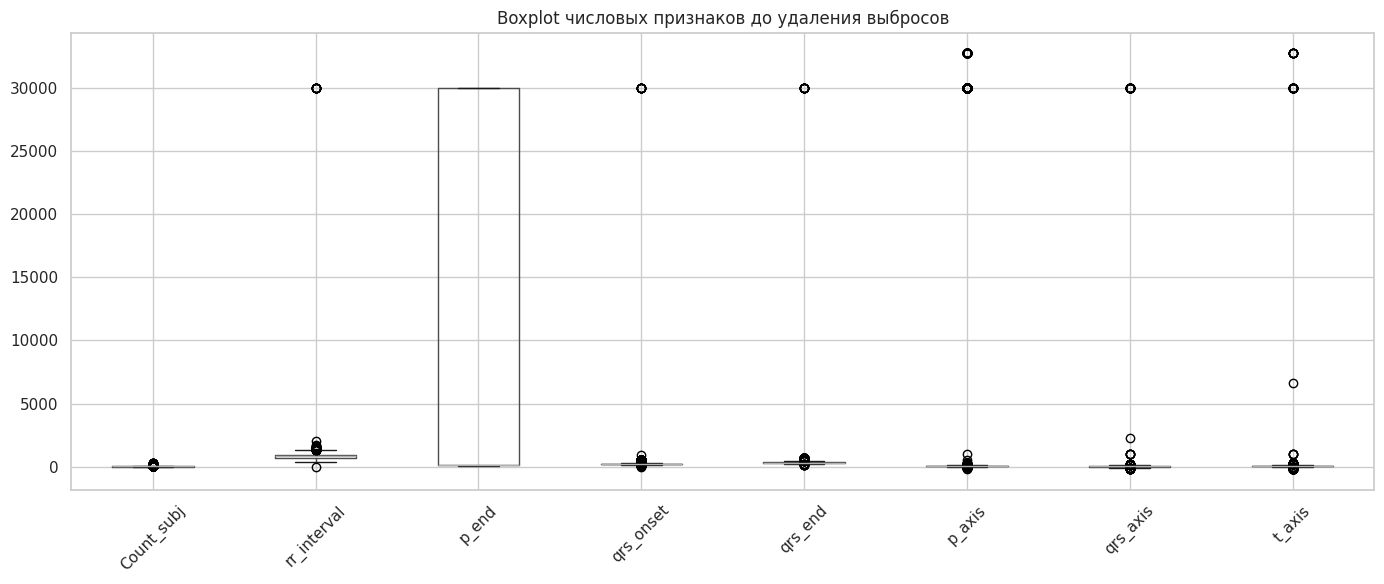

In [66]:
plt.figure(figsize=(14, 6))
df[feature_cols].boxplot(rot=45)
plt.title("Boxplot числовых признаков до удаления выбросов")
plt.tight_layout()
plt.savefig("figures_lab2/boxplot_before_cleaning.png", dpi=200, bbox_inches="tight")
plt.show()

In [67]:
def remove_outliers_iqr(dataframe: pd.DataFrame, cols: list) -> pd.DataFrame:
    cleaned = dataframe.copy()
    mask = pd.Series(True, index=cleaned.index)

    for col in cols:
        q1 = cleaned[col].quantile(0.25)
        q3 = cleaned[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        mask &= cleaned[col].between(lower, upper)

    return cleaned[mask].copy()

In [68]:
df_clean = remove_outliers_iqr(df, feature_cols)

print("Размер до удаления выбросов:", df.shape)
print("Размер после удаления выбросов:", df_clean.shape)

Размер до удаления выбросов: (5000, 9)
Размер после удаления выбросов: (2941, 9)


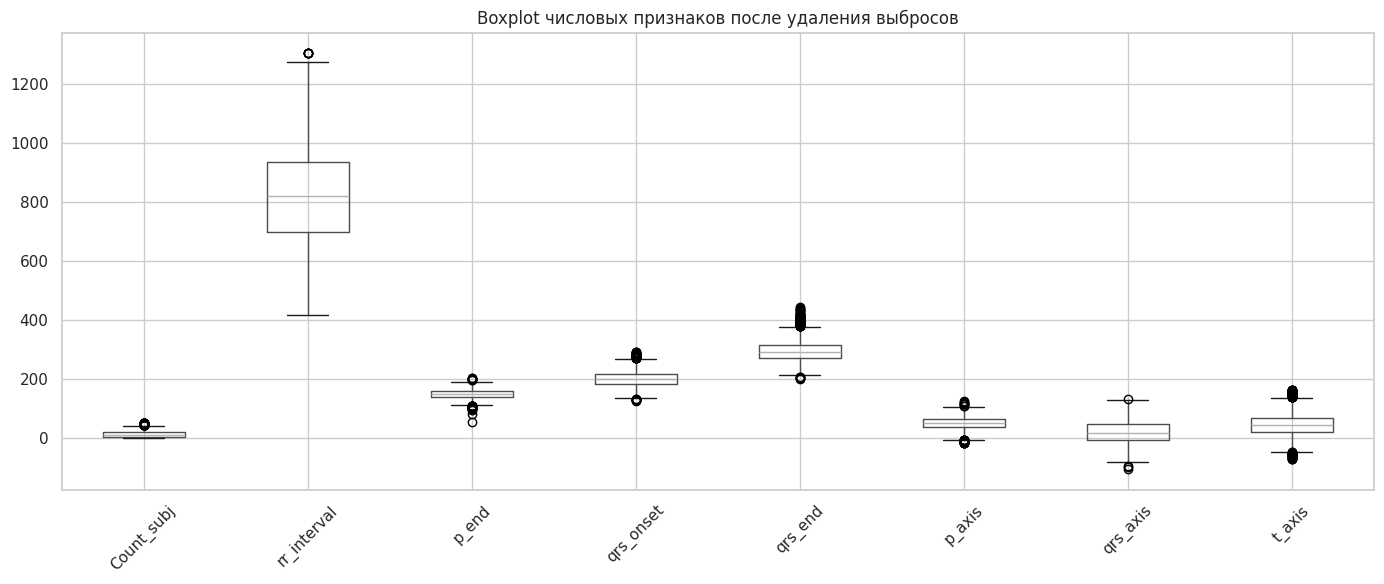

In [69]:
plt.figure(figsize=(14, 6))
df_clean[feature_cols].boxplot(rot=45)
plt.title("Boxplot числовых признаков после удаления выбросов")
plt.tight_layout()
plt.savefig("figures_lab2/boxplot_after_cleaning.png", dpi=200, bbox_inches="tight")
plt.show()

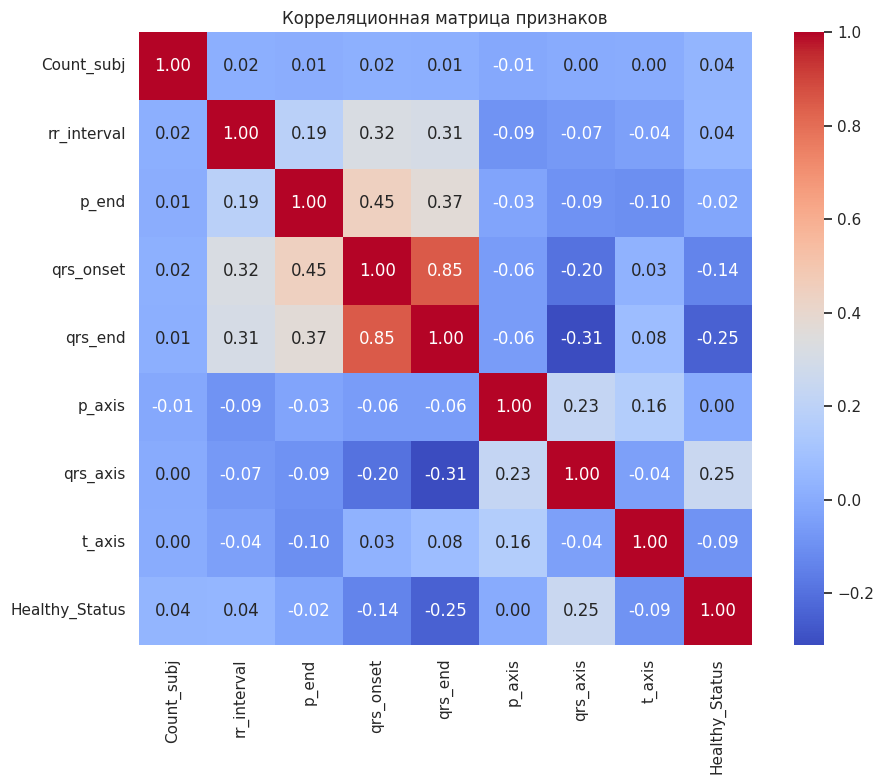

In [70]:
corr_df = df_clean.copy()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Корреляционная матрица признаков")
plt.tight_layout()
plt.savefig("figures_lab2/correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

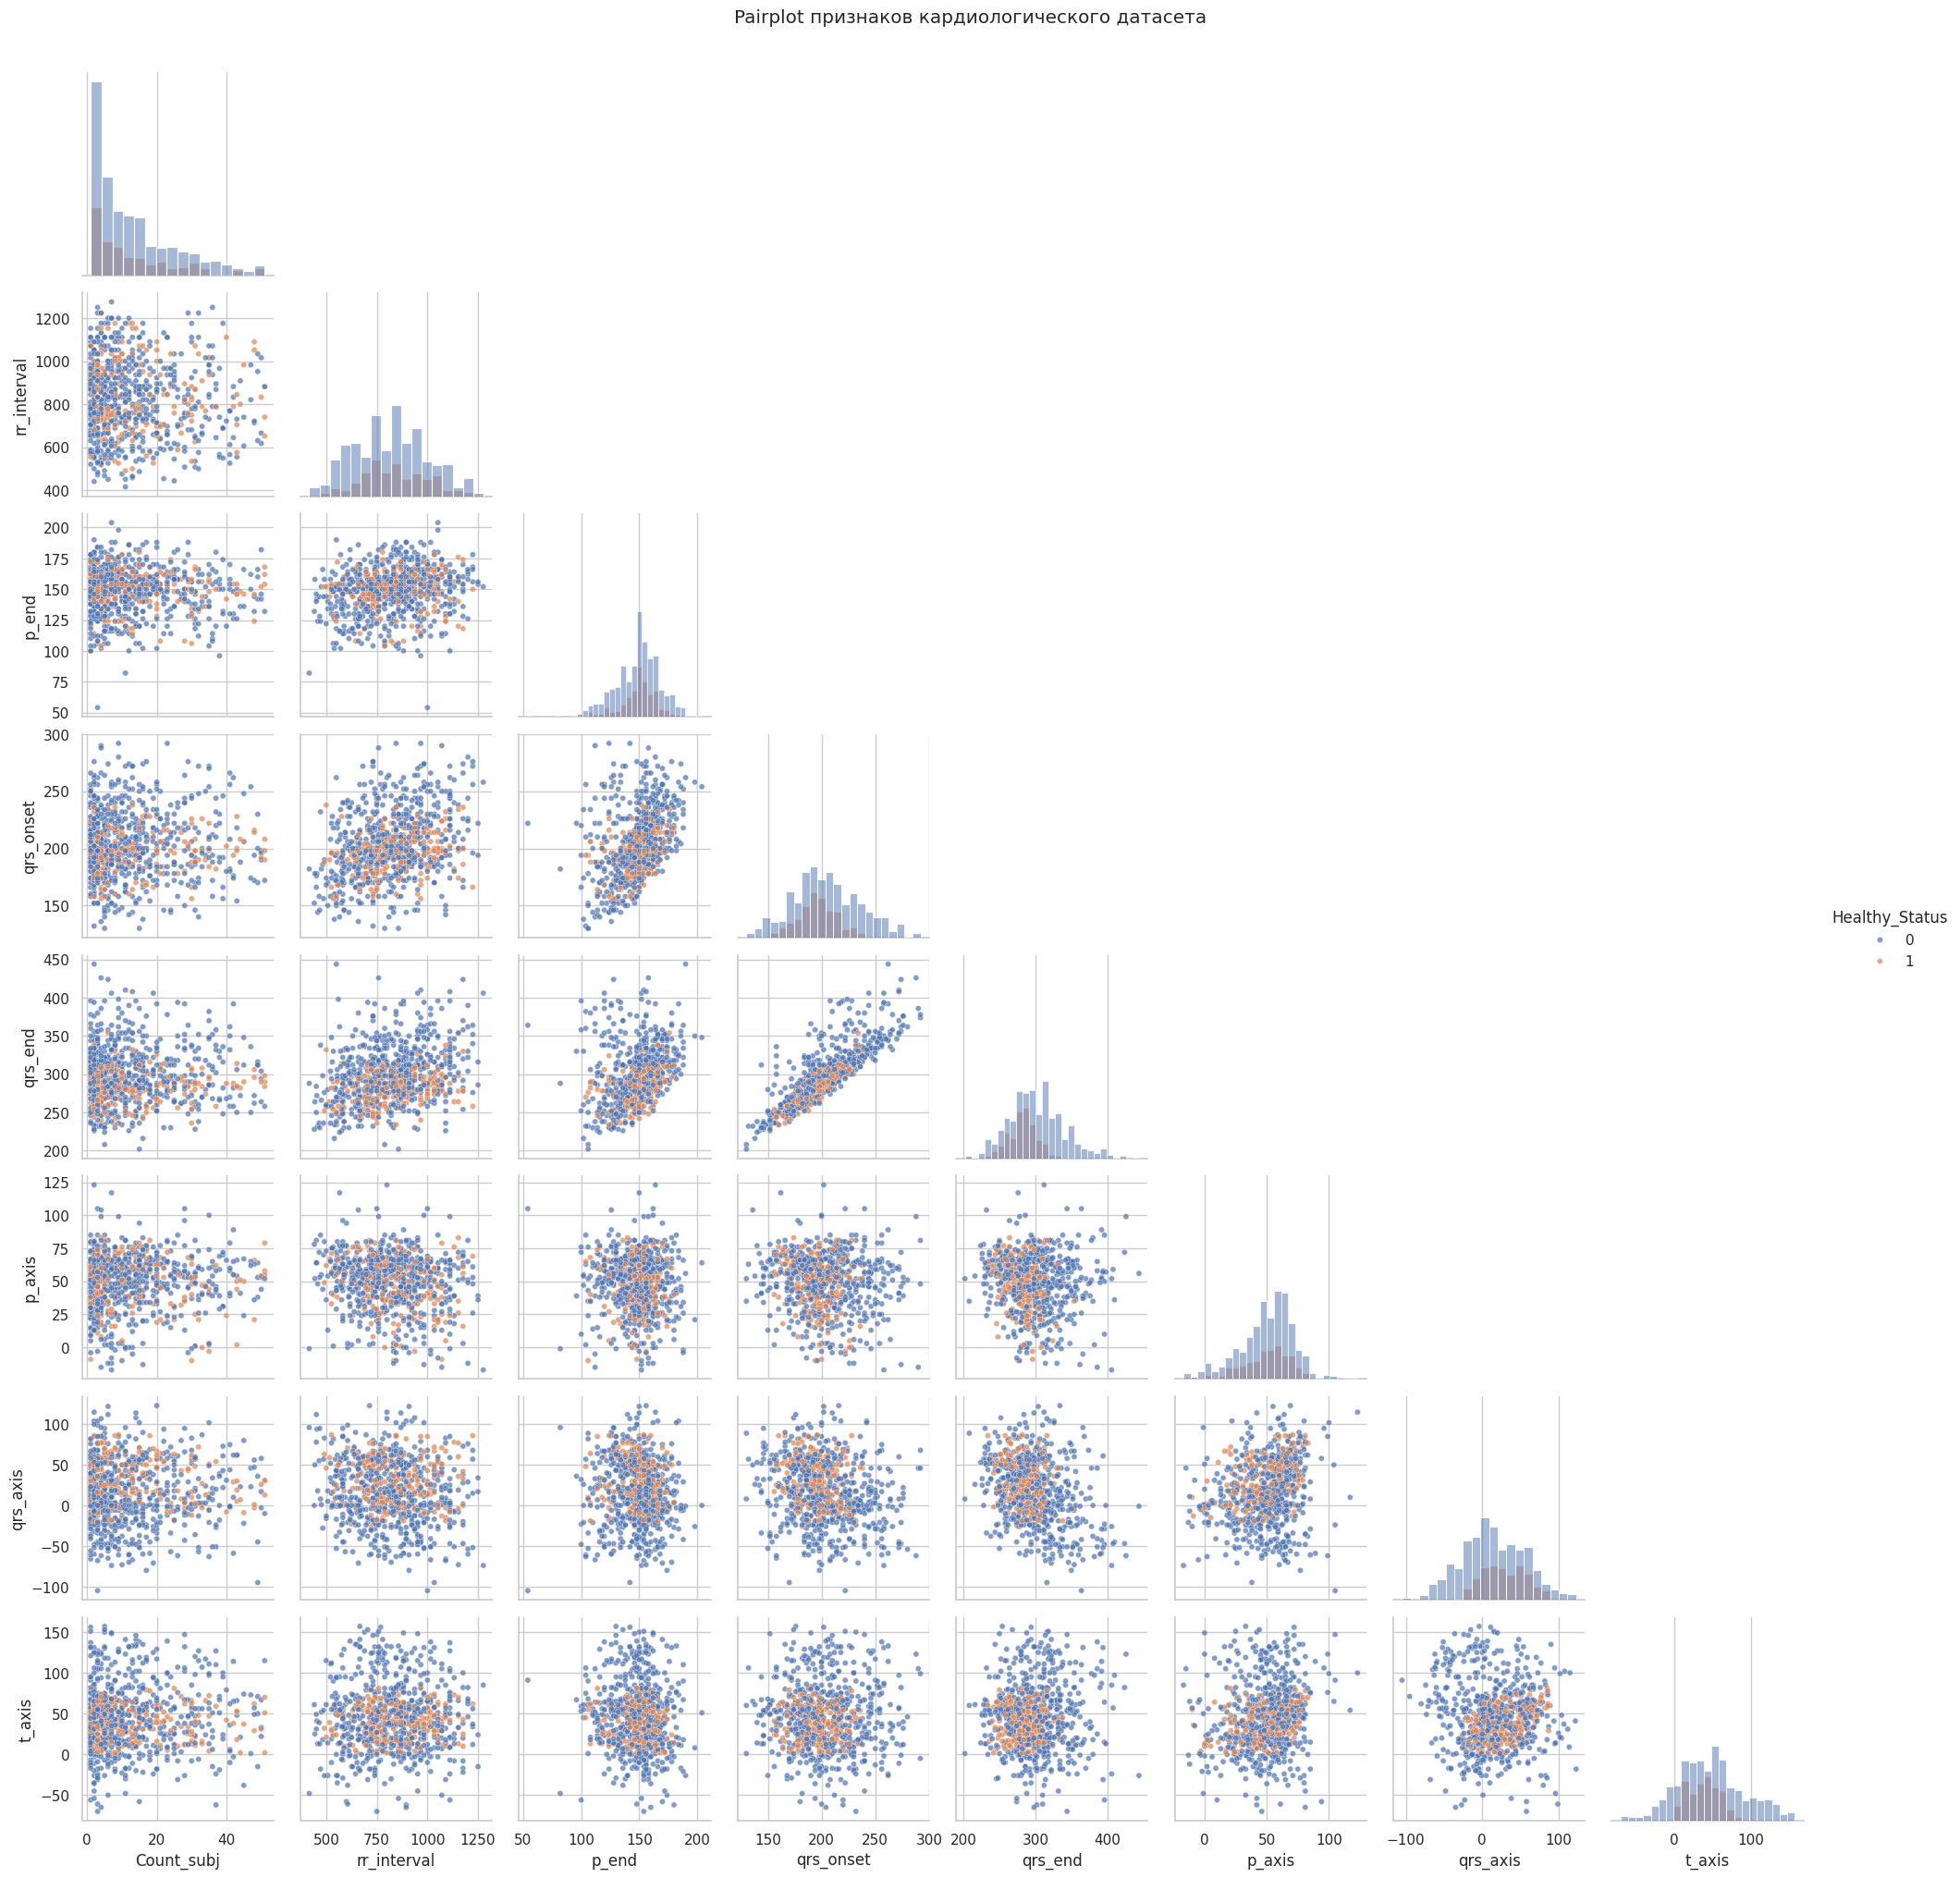

In [71]:
pairplot_sample = df_clean.sample(min(len(df_clean), 800), random_state=42)

g = sns.pairplot(
    pairplot_sample,
    vars=feature_cols,
    hue="Healthy_Status",
    diag_kind="hist",
    corner=True,
    plot_kws={"alpha": 0.7, "s": 20}
)
g.fig.suptitle("Pairplot признаков кардиологического датасета", y=1.02)
g.savefig("figures_lab2/pairplot_ecg.png", dpi=200, bbox_inches="tight")
plt.show()

In [72]:
X = df_clean[feature_cols].copy()
y = df_clean["Healthy_Status"].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Форма X:", X.shape)
print("Распределение классов:")
print(y.value_counts())

Форма X: (2941, 8)
Распределение классов:
Healthy_Status
0    2071
1     870
Name: count, dtype: int64


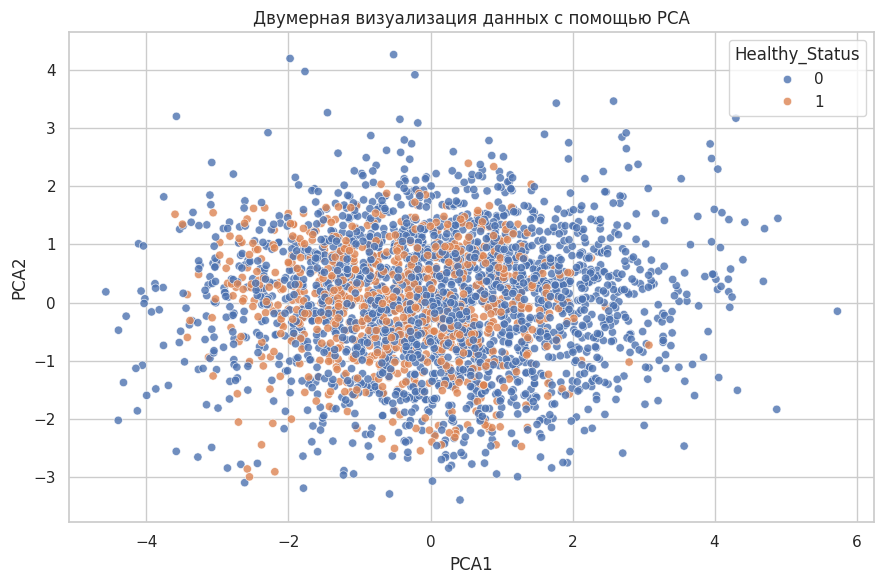

Explained variance ratio: [0.30404762 0.15104893]
Total explained variance: 0.45509654452810866


In [73]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PCA1", "PCA2"])
pca_df["Healthy_Status"] = y.values

plt.figure(figsize=(9, 6))
sns.scatterplot(data=pca_df, x="PCA1", y="PCA2", hue="Healthy_Status", alpha=0.8)
plt.title("Двумерная визуализация данных с помощью PCA")
plt.tight_layout()
plt.savefig("figures_lab2/pca_visualization.png", dpi=200, bbox_inches="tight")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

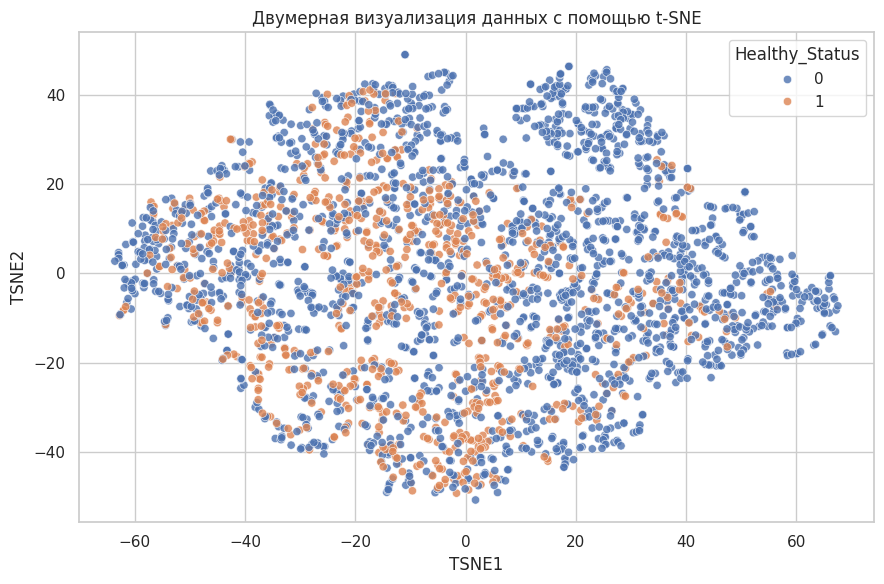

In [74]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame(X_tsne, columns=["TSNE1", "TSNE2"])
tsne_df["Healthy_Status"] = y.values

plt.figure(figsize=(9, 6))
sns.scatterplot(data=tsne_df, x="TSNE1", y="TSNE2", hue="Healthy_Status", alpha=0.8)
plt.title("Двумерная визуализация данных с помощью t-SNE")
plt.tight_layout()
plt.savefig("figures_lab2/tsne_visualization.png", dpi=200, bbox_inches="tight")
plt.show()

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (2352, 8)
Test shape: (589, 8)


In [76]:
automl = AutoML()

automl_settings = {
    "time_budget": 60,
    "metric": "f1",
    "task": "classification",
    "log_file_name": "flaml.log",
    "seed": 42,
    "estimator_list": ["rf", "extra_tree", "lrl1", "lrl2", "xgboost", "lgbm"]
}

automl.fit(X_train=X_train, y_train=y_train, **automl_settings)

print("Лучшая модель:", automl.best_estimator)
print("Лучшие гиперпараметры:", automl.best_config)

[flaml.automl.logger: 03-31 22:28:53] {2375} INFO - task = classification
[flaml.automl.logger: 03-31 22:28:53] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 03-31 22:28:53] {2489} INFO - Minimizing error metric: 1-f1
[flaml.automl.logger: 03-31 22:28:53] {2606} INFO - List of ML learners in AutoML Run: ['rf', 'extra_tree', 'lrl1', 'lrl2', 'xgboost', 'lgbm']
[flaml.automl.logger: 03-31 22:28:53] {2911} INFO - iteration 0, current learner rf
[flaml.automl.logger: 03-31 22:28:53] {3046} INFO - Estimated sufficient time budget=2681s. Estimated necessary time budget=26s.
[flaml.automl.logger: 03-31 22:28:53] {3097} INFO -  at 0.3s,	estimator rf's best error=1.0000e+00,	best estimator rf's best error=1.0000e+00
[flaml.automl.logger: 03-31 22:28:53] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 03-31 22:28:53] {3097} INFO -  at 0.3s,	estimator lgbm's best error=1.0000e+00,	best estimator rf's best error=1.0000e+00
[flaml.automl.logger: 03-31 22:28:53] {291

In [77]:
y_pred = automl.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy = {acc:.4f}")
print(f"F1-score = {f1:.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred))

Accuracy = 0.7538
F1-score = 0.6234

Classification report:

              precision    recall  f1-score   support

           0       0.86      0.78      0.82       415
           1       0.57      0.69      0.62       174

    accuracy                           0.75       589
   macro avg       0.71      0.74      0.72       589
weighted avg       0.77      0.75      0.76       589



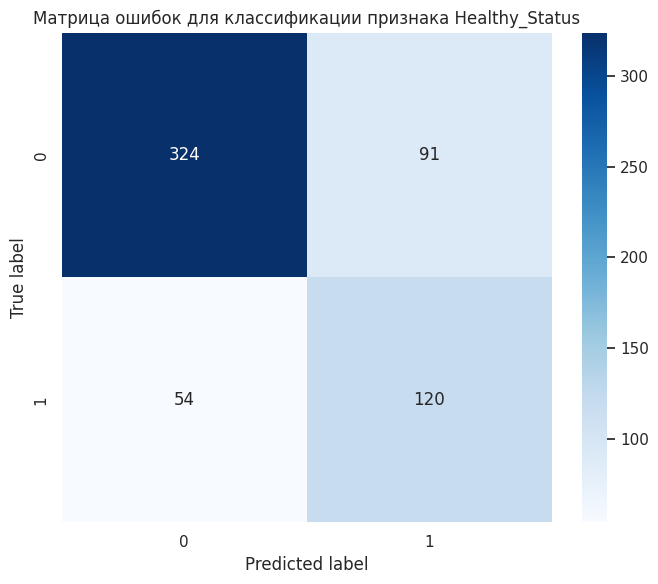

In [78]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Матрица ошибок для классификации признака Healthy_Status")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.savefig("figures_lab2/confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

In [79]:
with open("lab2_metrics.txt", "w", encoding="utf-8") as f:
    f.write(f"Best estimator: {automl.best_estimator}\n")
    f.write(f"Accuracy: {acc:.4f}\n")
    f.write(f"F1-score: {f1:.4f}\n")
    f.write("Best config:\n")
    f.write(str(automl.best_config))

print("Файл lab2_metrics.txt сохранен.")

Файл lab2_metrics.txt сохранен.


In [80]:
print("Готово. Все графики сохранены в папку figures_lab2.")

Готово. Все графики сохранены в папку figures_lab2.
